In [1]:
# -------------------------------
# BASIC LIBRARIES
# -------------------------------
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# TENSORFLOW / KERAS
# -------------------------------
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping

# -------------------------------
# EVALUATION
# -------------------------------
from sklearn.metrics import classification_report, confusion_matrix

2026-03-29 19:00:45.188465: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774810845.412313      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774810845.473922      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774810845.968068      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774810845.968115      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774810845.968118      55 computation_placer.cc:177] computation placer alr

In [2]:
train_dir = "/kaggle/input/datasets/divyasrimanivannan/lung-colon-preprocessed/Preprocessed_Dataset/train"
val_dir   = "/kaggle/input/datasets/divyasrimanivannan/lung-colon-preprocessed/Preprocessed_Dataset/val"
test_dir  = "/kaggle/input/datasets/divyasrimanivannan/lung-colon-preprocessed/Preprocessed_Dataset/test"

In [3]:
import os

print("Train classes:", os.listdir(train_dir))
print("Validation classes:", os.listdir(val_dir))
print("Test classes:", os.listdir(test_dir))

Train classes: ['colon_aca', 'lung_aca', 'lung_scc', 'colon_n', 'lung_n']
Validation classes: ['colon_aca', 'lung_aca', 'lung_scc', 'colon_n', 'lung_n']
Test classes: ['colon_aca', 'lung_aca', 'lung_scc', 'colon_n', 'lung_n']


In [4]:
print("\nTrain Count:")
for cls in os.listdir(train_dir):
    print(cls, len(os.listdir(os.path.join(train_dir, cls))))

print("\nValidation Count:")
for cls in os.listdir(val_dir):
    print(cls, len(os.listdir(os.path.join(val_dir, cls))))

print("\nTest Count:")
for cls in os.listdir(test_dir):
    print(cls, len(os.listdir(os.path.join(test_dir, cls))))


Train Count:
colon_aca 4000
lung_aca 4000
lung_scc 4000
colon_n 4000
lung_n 4000

Validation Count:
colon_aca 500
lung_aca 500
lung_scc 500
colon_n 500
lung_n 500

Test Count:
colon_aca 500
lung_aca 500
lung_scc 500
colon_n 500
lung_n 500


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image size & batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# -----------------------------
# Data Generators (ONLY rescale)
# -----------------------------
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

# -----------------------------
# Load Data
# -----------------------------
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False   # IMPORTANT for evaluation later
)

Found 20000 images belonging to 5 classes.
Found 2500 images belonging to 5 classes.
Found 2500 images belonging to 5 classes.


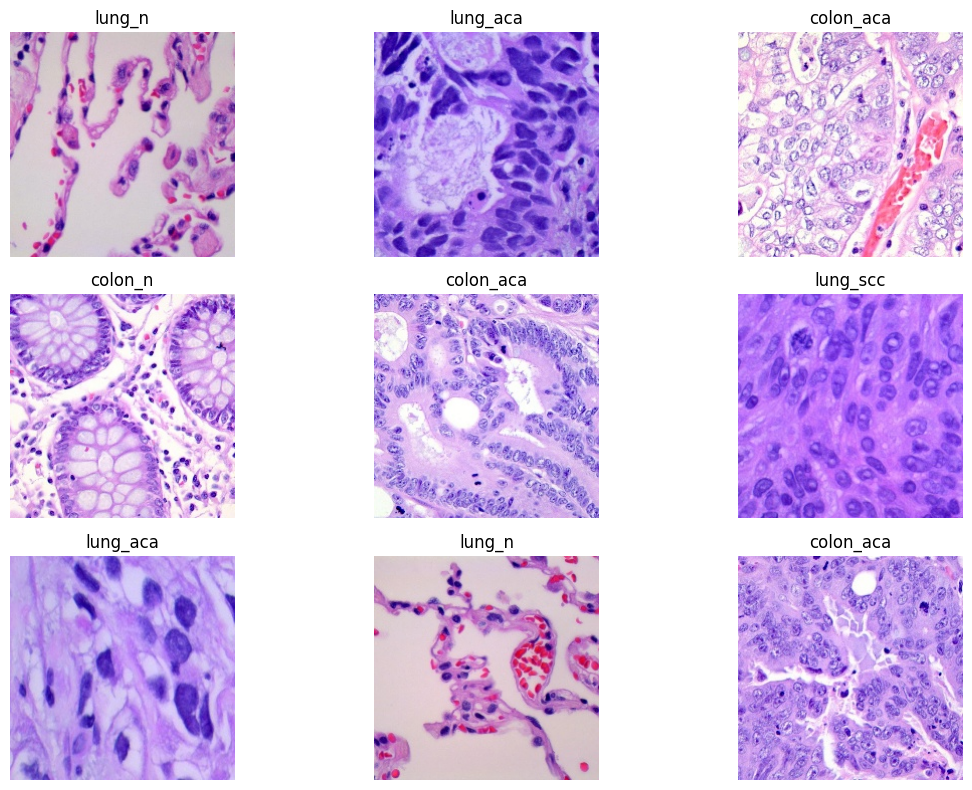

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch of images
images, labels = next(train_data)

# Class labels
class_names = list(train_data.class_indices.keys())

# Plot images
plt.figure(figsize=(12, 8))

for i in range(9):  # show 9 images
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    
    # Get label index
    label_index = np.argmax(labels[i])
    plt.title(class_names[label_index])
    
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
print("Class Indices Mapping:")
print(train_data.class_indices)

Class Indices Mapping:
{'colon_aca': 0, 'colon_n': 1, 'lung_aca': 2, 'lung_n': 3, 'lung_scc': 4}


In [8]:
# -------------------------------
# LOAD PRETRAINED RESNET50
# -------------------------------
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# -------------------------------
# FREEZE BASE MODEL
# -------------------------------
for layer in base_model.layers:
    layer.trainable = False

# -------------------------------
# ADD CUSTOM CLASSIFIER
# -------------------------------
x = base_model.output

# Global pooling (better than Flatten)
x = GlobalAveragePooling2D()(x)

# Dense layer (feature learning)
x = Dense(256, activation='relu')(x)

# Dropout (reduce overfitting)
x = Dropout(0.5)(x)

# Output layer (5 classes)
outputs = Dense(5, activation='softmax')(x)

# -------------------------------
# FINAL MODEL
# -------------------------------
model = Model(inputs=base_model.input, outputs=outputs)

# -------------------------------
# MODEL SUMMARY
# -------------------------------
model.summary()

I0000 00:00:1774810977.761330      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [9]:
# -------------------------------
# COMPILE MODEL
# -------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

callbacks = [early_stop, lr_scheduler, checkpoint]

In [11]:
# -------------------------------
# TRAIN MODEL
# -------------------------------
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1774811019.955562     162 service.cc:152] XLA service 0x792578013ec0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774811019.955612     162 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774811022.318531     162 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/625 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.1641 - loss: 2.0587   

I0000 00:00:1774811027.252380     162 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.7637 - loss: 0.5943 - val_accuracy: 0.7972 - val_loss: 0.5393 - learning_rate: 1.0000e-04
Epoch 41/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7701 - loss: 0.5893
Epoch 41: val_accuracy did not improve from 0.79720
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 79ms/step - accuracy: 0.7701 - loss: 0.5893 - val_accuracy: 0.7940 - val_loss: 0.5252 - learning_rate: 1.0000e-04
Epoch 42/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7726 - loss: 0.5800
Epoch 42: val_accuracy did not improve from 0.79720
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 78ms/step - accuracy: 0.7726 - loss: 0.5800 - val_accuracy: 0.7908 - val_loss: 0.5285 - learning_rate: 1.0000e-04
Epoch 43/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7719 - loss: 0.5782
Epoch 43: val_accuracy improved from 0.79720 to 0.79840, saving model to best_model.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step - accuracy: 0.7719 - loss: 0.5782 - val_accuracy: 0.7984 - val_loss: 0.5248 - learning_rate: 1.0000e-04
Epoch 44/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7620 - loss: 0.5828
Epoch 44: val_accuracy did not improve from 0.79840
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.7620 - loss: 0.5828 - val_accuracy: 0.7904 - val_loss: 0.5244 - learning_rate: 1.0000e-04
Epoch 45/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7744 - loss: 0.5699
Epoch 45: val_accuracy improved from 0.79840 to 0.79920, saving model to best_model.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 81ms/step - accuracy: 0.7744 - loss: 0.5699 - val_accuracy: 0.7992 - val_loss: 0.5218 - learning_rate: 1.0000e-04
Epoch 46/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.7731 - loss: 0.5780
Epoch 46: val_accuracy did not improve from 0.79920
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 85ms/step - accuracy: 0.7731 - loss: 0.5779 - val_accuracy: 0.7952 - val_loss: 0.5142 - learning_rate: 1.0000e-04
Epoch 47/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.7777 - loss: 0.5595
Epoch 47: val_accuracy did not improve from 0.79920
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.7777 - loss: 0.5596 - val_accuracy: 0.7976 - val_loss: 0.5111 - learning_rate: 1.0000e-04
Epoch 48/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.7787 - loss: 0.5604
Epoch 48: val_accuracy did not improve from 0.79920
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.7787 - loss: 0.5605 - val_accuracy: 0.7872 - val_loss: 0.5292 - learning_rate: 1.0

625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.7751 - loss: 0.5603 - val_accuracy: 0.8000 - val_loss: 0.5083 - learning_rate: 1.0000e-04
Epoch 50/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7778 - loss: 0.5497
Epoch 50: val_accuracy improved from 0.80000 to 0.80880, saving model to best_model.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.7778 - loss: 0.5497 - val_accuracy: 0.8088 - val_loss: 0.5076 - learning_rate: 1.0000e-04


In [13]:
for layer in base_model.layers[-50:]:   # earlier maybe 20? now increase
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # lower LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5845 - loss: 5.6358
Epoch 1: val_accuracy improved from 0.80880 to 0.82120, saving model to best_model.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 108ms/step - accuracy: 0.5846 - loss: 5.6297 - val_accuracy: 0.8212 - val_loss: 0.4886 - learning_rate: 1.0000e-05
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.7848 - loss: 0.5301
Epoch 2: val_accuracy improved from 0.82120 to 0.83440, saving model to best_model.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.7848 - loss: 0.5300 - val_accuracy: 0.8344 - val_loss: 0.4314 - learning_rate: 1.0000e-05
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8078 - loss: 0.4730
Epoch 3: val_accuracy improved from 0.83440 to 0.87560, saving model to best_model.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.8079 - loss: 0.4730 - val_accuracy: 0.8756 - val_loss: 0.3296 - learning_rate: 1.0000e-05
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8326 - loss: 0.4161
Epoch 4: val_accuracy did not improve from 0.87560
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.8326 - loss: 0.4161 - val_accuracy: 0.7748 - val_loss: 0.6380 - learning_rate: 1.0000e-05
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8606 - loss: 0.3570
Epoch 5: val_accuracy did not improve from 0.87560
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.8606 - loss: 0.3570 - val_accuracy: 0.6604 - val_loss: 1.3083 - learning_rate: 1.0000e-05
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8629 - loss: 0.3449
Epoch 6: val_accuracy improved from 0.87560 to 0.90080, saving model to best_model.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.8629 - loss: 0.3449 - val_accuracy: 0.9008 - val_loss: 0.2585 - learning_rate: 1.0000e-05
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8833 - loss: 0.2996
Epoch 7: val_accuracy did not improve from 0.90080
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.8833 - loss: 0.2996 - val_accuracy: 0.8456 - val_loss: 0.3939 - learning_rate: 1.0000e-05
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8754 - loss: 0.3071
Epoch 8: val_accuracy did not improve from 0.90080
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.8754 - loss: 0.3071 - val_accuracy: 0.8632 - val_loss: 0.3497 - learning_rate: 1.0000e-05
Epoch 9/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.8877 - loss: 0.2836
Epoch 9: val_accuracy did not improve from 0.90080
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.8877 - loss: 0.2836 - val_accuracy: 0.9000 - val_loss: 0.2752 - learning_rate: 1.0000e-0

625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.9222 - loss: 0.1995 - val_accuracy: 0.9312 - val_loss: 0.1925 - learning_rate: 2.0000e-06


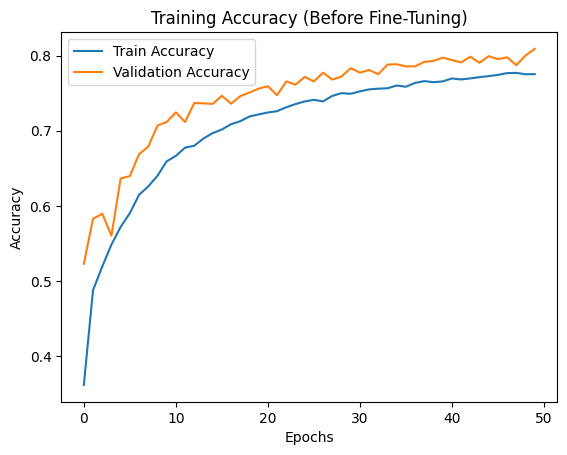

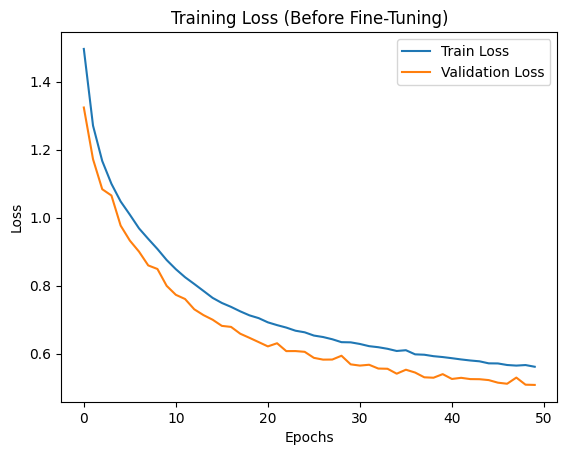

In [14]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Training Accuracy (Before Fine-Tuning)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training Loss (Before Fine-Tuning)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

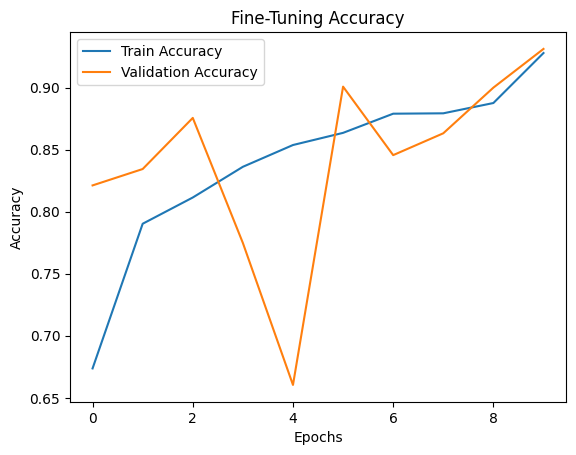

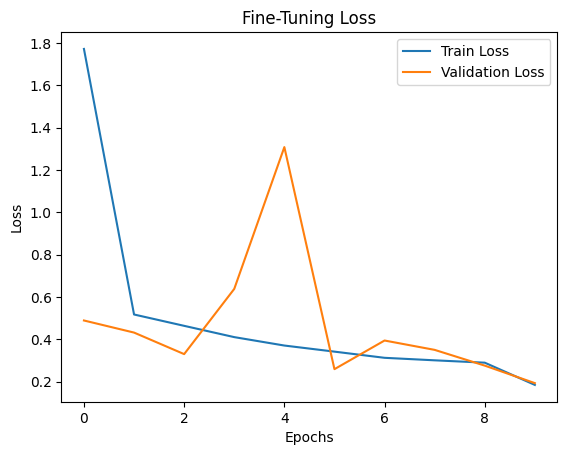

In [15]:
# Accuracy
plt.plot(history_fine.history['accuracy'], label='Train Accuracy')
plt.plot(history_fine.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Fine-Tuning Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# Loss
plt.plot(history_fine.history['loss'], label='Train Loss')
plt.plot(history_fine.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Fine-Tuning Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [16]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 171ms/step - accuracy: 0.9434 - loss: 0.1709
Test Accuracy: 0.9308000206947327


79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 122ms/step


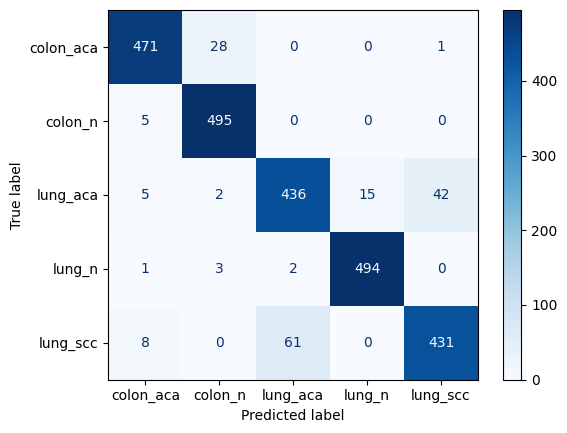

In [17]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_data.class_indices.keys())
disp.plot(cmap='Blues')

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes, target_names=list(test_data.class_indices.keys())))

              precision    recall  f1-score   support

   colon_aca       0.96      0.94      0.95       500
     colon_n       0.94      0.99      0.96       500
    lung_aca       0.87      0.87      0.87       500
      lung_n       0.97      0.99      0.98       500
    lung_scc       0.91      0.86      0.89       500

    accuracy                           0.93      2500
   macro avg       0.93      0.93      0.93      2500
weighted avg       0.93      0.93      0.93      2500



In [19]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.preprocessing import image

# -------------------------------
# Function to generate Grad-CAM
# -------------------------------
def get_gradcam(img_array, model, last_conv_layer_name):
    
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

In [22]:
# Path to image (use any test image)
img_path = '/kaggle/input/datasets/divyasrimanivannan/lung-colon-preprocessed/Preprocessed_Dataset/test/lung_aca/lungaca108.jpeg'

# Load image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Generate heatmap
heatmap = get_gradcam(img_array, model, last_conv_layer_name='conv5_block3_out')

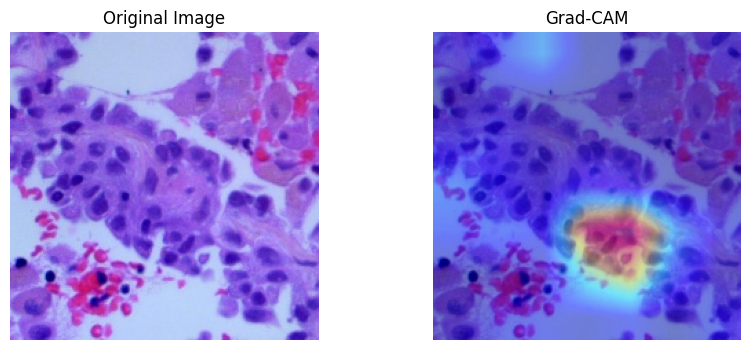

In [23]:
# Convert heatmap to RGB
heatmap = cv2.resize(heatmap, (224, 224))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Load original image
img_original = cv2.imread(img_path)
img_original = cv2.resize(img_original, (224, 224))

# Superimpose
superimposed_img = cv2.addWeighted(img_original, 0.6, heatmap, 0.4, 0)

# Display
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM")
plt.axis('off')

plt.show()